# Seismic Oceanography: Inversion via Genetic Algorithms

This notebook orchestrates the inversion workflow to estimate the physical properties of the water column (specifically the P-wave velocity, $V_p$) by optimizing EOF (Empirical Orthogonal Function) coefficients.

To ensure robust implementation, a smoothed velocity model is utilized here for algorithm validation (synthetic testing). The optimization is handled via the DEAP framework to perform a global search and minimize the phase misfit between the synthetic and observed seismic traces.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import multiprocessing
from deap import algorithms, tools
import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

import time
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Internal modules
from ocean_inversion.config import (FOLDER_NAME,FOLDER_OUTPUT,MODEL_VP0,MODEL_RHO0,MODEL_EOFS,MODEL_COEF_HIST,MARGEM_COEF,
                                    DZ,DT,NT,F_PEAK,Z_MAX,ADD_NOISE,PERCENTAGE_NOISE,
                                    SEED, N_INV, NUM_PROCESS, POPULATION, CXPB, MUTPB, NGEN, TOURNSIZE,HOF_NUM,ETA_GENE)


from ocean_inversion.evolutionary_algorithm import (
    init_worker,
    configure_deap_ocean,
    statistics_save
)

from ocean_inversion.modeling import (
    mute_direct_arrival,normalize_data,
    calculate_synthetic_trace,ricker_wavelet,
    geometric_spreading_correction,bandpass_filter,
    crop_seismogram_by_depth,add_white_noise,apply_edge_taper
)



[ocean_inversion.config] Reading configuration file: /home/sysop/diogogit/NFH_inversion_seismic_oceanography/config_file.cnf


/home/sysop/Programs/anaconda3/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [2]:
data_path = FOLDER_OUTPUT+FOLDER_NAME+'/DATA/'

### Directory for saving figures: 

In [3]:
figures_path = FOLDER_OUTPUT+FOLDER_NAME+'/FIGURES/'

## 1. Data Loading and Setup

In this section, we load the required datasets: the baseline velocity model, the EOF basis vectors, the density model ($\rho$), and the observed seismic traces. We also define the seismic configuration parameters such as peak frequency and sampling rate to generate the source wavelet.

In [4]:
# Load EOF basis and base models (example using xarray and numpy)
vp_base = np.load(MODEL_VP0)

rho_model = np.load(MODEL_RHO0)

eof_basis=np.load(MODEL_EOFS)

coef_hist=np.load(MODEL_COEF_HIST)

low = coef_hist.min(axis=1)
high = coef_hist.max(axis=1)

faixa = high - low
coef_mins = low - MARGEM_COEF * faixa
coef_maxs = high + MARGEM_COEF * faixa


## 1.1 Observed data

In [5]:
device = torch.device("cpu")

ds = xr.open_zarr("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/dados_observados/ocean_data_synthetic.zarr")

subset = ds.amplitude.isel(shot=slice(0, 1),receiver=slice(0, 1)).load()

observed_data = torch.as_tensor(subset.values,dtype=torch.float32,device=device).numpy().squeeze()


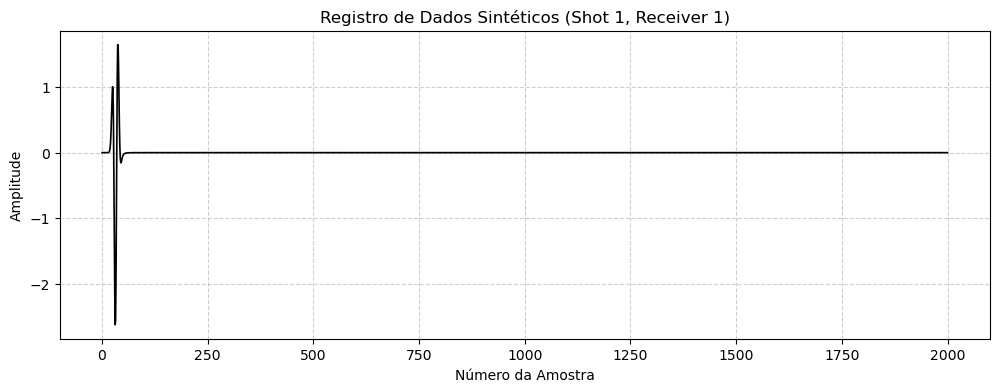

In [6]:
import matplotlib.pyplot as plt

# Cria a figura com um tamanho adequado (largura, altura)
plt.figure(figsize=(12, 4))

# Plota os dados
plt.plot(observed_data, color='black', linewidth=1.2)

# Adiciona títulos e rótulos aos eixos
plt.title("Registro de Dados Sintéticos (Shot 1, Receiver 1)")
plt.xlabel("Número da Amostra")
plt.ylabel("Amplitude")

# Adiciona um grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico na tela
plt.show()

## 1.2 Removing direct wave from Observed data

In [7]:
s_obs = geometric_spreading_correction(observed_data, dt=DT, mode="cylindrical")

s_obs = mute_direct_arrival(
    trace=s_obs,
    offset=25,
    dt=DT,
    freq=F_PEAK,
    peak_time=1.5/F_PEAK
)

if ADD_NOISE: 
    s_obs = add_white_noise(s_obs, PERCENTAGE_NOISE)

s_obs = mute_direct_arrival(
    trace=s_obs,
    offset=25,
    dt=DT,
    freq=F_PEAK,
    peak_time=1.5/F_PEAK
)

s_obs = bandpass_filter(s_obs, dt=DT, f_peak=F_PEAK) 

s_obs = crop_seismogram_by_depth(seismogram=s_obs, base_model=vp_base, dz=DZ, dt=DT, z_max=Z_MAX)

s_norm = normalize_data(s_obs,method="trace_max")


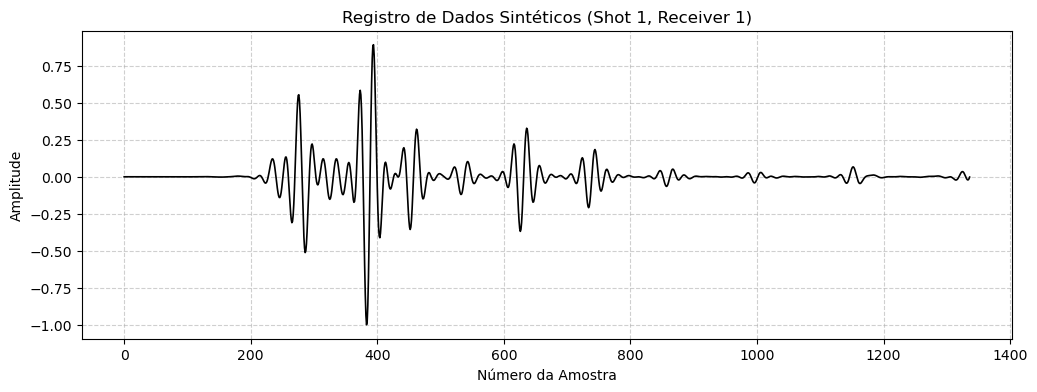

In [8]:
# Cria a figura com um tamanho adequado (largura, altura)
plt.figure(figsize=(12, 4))

# Plota os dados
plt.plot(s_norm, color='black', linewidth=1.2)

# Adiciona títulos e rótulos aos eixos
plt.title("Registro de Dados Sintéticos (Shot 1, Receiver 1)")
plt.xlabel("Número da Amostra")
plt.ylabel("Amplitude")

# Adiciona um grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico na tela
plt.show()

## 2. Genetic Algorithm Configuration

Here we configure the Distributed Evolutionary Algorithms in Python (DEAP) framework. We set the boundaries for the EOF coefficients and map the parallel processing pool. The fitness evaluation relies on the phase misfit objective function imported from our modules.

In [9]:
# --------------
# Saving results

dic_inversion = []

start_time = time.time()

# ----------
# GLOBAL RNG

main_rng = np.random.default_rng(SEED)

# ----------------
# INVERSION SCHEME

with multiprocessing.Pool(processes=NUM_PROCESS, initializer=init_worker, initargs=(SEED,)) as pool:

    for ivx in tqdm(range(N_INV),total=len(range(N_INV)),desc='Number of inversions', leave=True, dynamic_ncols=True,colour='green'):

        # --------------
        # Starting DEAP:
                            
        # Parameters (Space search) and configuration:
        toolbox = configure_deap_ocean(vp_base, eof_basis, coef_mins, coef_maxs, s_norm, F_PEAK, DT, DZ, NT,Z_MAX, rho_model, ETA_GENE, MUTPB, TOURNSIZE, pool.map, main_rng)

        # Starting population:
        population = toolbox.population(n=POPULATION)
        
        # Saving starting population:
        population_first = [toolbox.clone(ind) for ind in population]

        # Starting statistical measurement:
        estatistica = tools.Statistics(statistics_save)
        estatistica.register('mean', np.mean)
        estatistica.register('min', np.min)
        estatistica.register('max', np.max)

        # Starting best solution estimation:
        hof = tools.HallOfFame(HOF_NUM)
                        
        # Starting the algorithm
        result, log = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN,stats=estatistica, halloffame=hof, verbose=False)
        
        # -----------------------------------------------------------------------------------
        # Saving HOF inversion results 
                
        dic_results = {
                        'ssp': [vp_base + np.dot(eof_basis,ind) for ind in hof],
                        'pop': [vp_base + np.dot(eof_basis,ind) for ind in population_first],
                        'misfit': [i['mean'] for i in log],
                        'ngen': [i['gen'] for i in log],
                        'inversion': ivx + 1}
                    
        dic_inversion.append(dic_results)

Number of inversions: 100%|██████████| 10/10 [01:38<00:00,  9.83s/it]


## **Saving the results:**

In [10]:
df_inversion = pd.DataFrame.from_dict(dic_inversion)
df_inversion.to_feather(data_path+'inversion.feather')

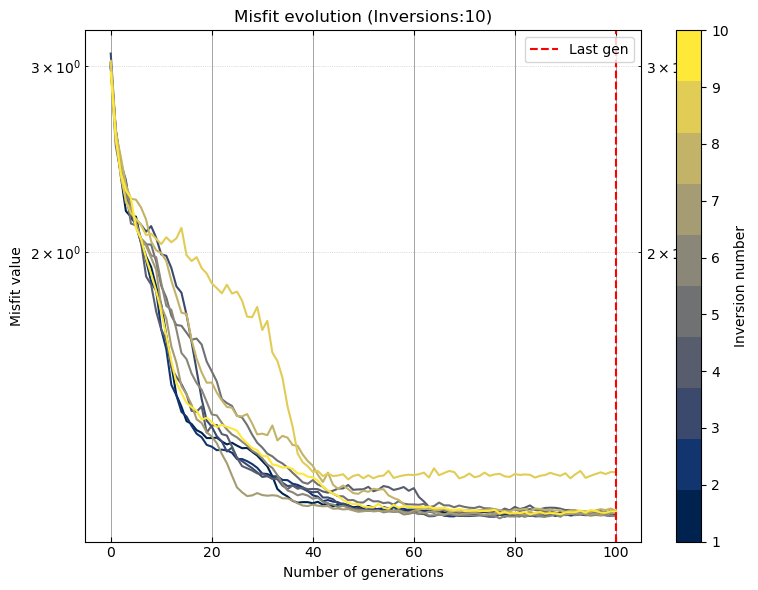

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# One color per survey
norm = plt.Normalize(vmin=df_inversion['inversion'].values.min(), vmax=df_inversion['inversion'].values.max())


cmap = plt.get_cmap('cividis', len(df_inversion['inversion'].values))

for dativ in df_inversion.iterrows():
    color = cmap(norm(dativ[1]['inversion']))
    ax.semilogy(dativ[1]['ngen'], dativ[1]['misfit'], '-',color=color)
        
ax.set_xlabel('Number of generations')
ax.set_ylabel('Misfit value')
ax.axvline(x=len(dativ[1]['ngen'])-1, color='red', linestyle='--', label='Last gen')
ax.legend(loc='upper right')
ax.grid(True, which='both')
ax.tick_params(axis='both', which='both', direction='in',top=True, bottom=True, left=True, right=True,labelbottom=True, labeltop=False, labelleft=True,labelright=True)
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_title('Misfit evolution'+' (Inversions:'+str(N_INV)+')')

# ScalarMappable to colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Colorbar
cbar = plt.colorbar(sm, ax=ax, ticks=df_inversion['inversion'].values)
cbar.set_label("Inversion number")
plt.tight_layout()

fig.savefig(figures_path+FOLDER_NAME+'_model_misfit_evolution.png', dpi=300)